# Markov Decision Processes (MDPs) and Value Iteration

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Markov Decision Processes (MDPs) fundamentals
- Implement simple MDPs and value iteration algorithms
- See how MDPs form the foundation of reinforcement learning
- Apply value iteration to solve decision-making problems

## 🔗 Where this fits

**Builds on:** Course 02 — Unit 3, lesson 03 "Hidden Markov Models" — the same Markov assumption, now with actions you choose and rewards you collect.

**Used later in:** Course 09 (AIAT 123) — Unit 1, which starts from exactly this MDP and value iteration and builds reinforcement learning on top.

---

This notebook covers practical activities from **Course 02, Unit 3**:
- Introduction to the MDP framework that underlies reinforcement learning (full RL environments and agents come later in the diploma)
- Implementing simple MDPs and value iteration algorithms

---

## Introduction to MDPs

**Markov Decision Processes (MDPs)** are mathematical frameworks for modeling decision-making in situations where outcomes are partly random and partly under control.


## 🌍 The case: the rule in every warehouse in the world

**RAND Corporation, 1950s.** Richard Bellman formulated the Markov decision process and the equation that carries his name (reference 1 below) for sequential decision problems in operations research — inventory, maintenance, resource allocation. Not for games.

**Inventory, 1960.** Herbert Scarf proved that for the standard stochastic inventory problem with a fixed ordering cost, the *optimal* policy has a remarkably simple shape: **when stock falls to or below a level `s`, order back up to a level `S`** — nothing else, ever. That result (*The Optimality of (s, S) Policies in the Dynamic Inventory Problem*, 1960, proved with a tool he invented for it called K-convexity) is why (s, S) rules remain the standard shape of replenishment policies in retail and distribution to this day. Somebody solved the MDP once; the answer became a business rule that buyers apply without knowing where it came from.

**Games and beyond, 2020.** **MuZero** (Schrittwieser *et al.*, Nature 588, 604–609 — reference 2) mastered Go, chess, shogi and Atari by *learning* the transition and reward model and then planning inside it. The framework it plans in is the one on this page.

### What goes wrong without this

Decide greedily and you decide badly, in a way that is invisible at the moment of deciding. A buyer who orders whatever minimises this week's cost stocks out next month. A robot that always takes the cheapest immediate move walks into the dead end. A recommender that always shows the highest-click-probability item trains its users to stop trusting it.

The MDP is the smallest model in which "cheap now, expensive later" can even be *written down*, and value iteration is the proof that a full plan can be **computed from the model**, with no trial and error at all. Watch for one number in the output below: `V*(S2) = 100`, while the immediate reward for being in S2 is only 10. The value of a state is not its reward — it is everything that follows from it. That gap is the entire subject.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt   # we do not only print the values - we watch them move

print("✅ Libraries imported!")
print("Ready to work with MDPs and Value Iteration!")


✅ Libraries imported!
Ready to work with MDPs and Value Iteration!


## Part 1: Simple MDP Implementation

Let's create a simple grid world MDP.


In [2]:
# Define a Markov Decision Process: states, actions, stochastic transitions, and rewards.
# Why: an MDP is the standard model for sequential decisions where actions have uncertain outcomes -
# every later reinforcement-learning method in the diploma assumes exactly this structure.

class SimpleMDP:
    """Simple Markov Decision Process implementation"""
    
    def __init__(self, states, actions, transitions, rewards, gamma=0.9):
        """
        Parameters:
        - states: List of states
        - actions: List of actions
        - transitions: Dict[state][action][next_state] = probability
        - rewards: Dict[state][action] = reward
        - gamma: Discount factor
        """
        self.states = states
        self.actions = actions
        self.transitions = transitions
        self.rewards = rewards
        self.gamma = gamma
    
    def get_reward(self, state, action):
        """Get reward for state-action pair"""
        return self.rewards.get(state, {}).get(action, 0.0)
    
    def get_transition_prob(self, state, action, next_state):
        """Get transition probability P(next_state | state, action)"""
        return self.transitions.get(state, {}).get(action, {}).get(next_state, 0.0)

# Example: Simple 3-state MDP
states = ['S0', 'S1', 'S2']
actions = ['Left', 'Right']

# Transition probabilities: P(next_state | current_state, action)
transitions = {
    'S0': {
        'Left': {'S0': 0.8, 'S1': 0.2},
        'Right': {'S1': 0.9, 'S2': 0.1}
    },
    'S1': {
        'Left': {'S0': 0.7, 'S1': 0.3},
        'Right': {'S1': 0.5, 'S2': 0.5}
    },
    'S2': {
        'Left': {'S1': 1.0},
        'Right': {'S2': 1.0}  # Absorbing state: 'Right' in S2 loops back to S2 forever
    }
}

# Rewards: R(state, action)
rewards = {
    'S0': {'Left': -1, 'Right': 0},
    'S1': {'Left': 0, 'Right': 5},
    'S2': {'Left': 0, 'Right': 10}  # S2 is the goal: staying 'Right' collects +10 EVERY step
}

mdp = SimpleMDP(states, actions, transitions, rewards)

print("=" * 60)
print("Simple MDP: Grid World")
print("=" * 60)
print(f"States: {states}")
print(f"Actions: {actions}")
print(f"Discount factor (gamma): {mdp.gamma}")

Simple MDP: Grid World
States: ['S0', 'S1', 'S2']
Actions: ['Left', 'Right']
Discount factor (gamma): 0.9


## Part 2: Value Iteration Algorithm

Value iteration computes the optimal value function V*(s) for all states.

One thing to watch for in the output: S2 is an **absorbing goal state** — the `Right` action loops back to S2 and collects +10 on every step. With discount factor γ = 0.9, its optimal value is the geometric series

$$V^*(S_2) = 10 + 10\gamma + 10\gamma^2 + \dots = \frac{10}{1-\gamma} = 100$$

so a value near 100 (not 10) is exactly right.


In [3]:
# Value iteration: repeatedly apply the Bellman optimality update until values stop changing,
# then read off the optimal policy (best action per state).
# Why: this shows an optimal plan can be COMPUTED from the model - no trial-and-error learning needed.

def value_iteration(mdp, theta=1e-6, max_iterations=500):
    """
    Value iteration algorithm to find optimal value function
    
    Parameters:
    - mdp: MDP object
    - theta: Convergence threshold
    - max_iterations: Maximum iterations
    
    Returns:
    - V: Optimal value function
    - policy: Optimal policy
    """
    # Initialize value function
    V = {state: 0.0 for state in mdp.states}
    
    for iteration in range(max_iterations):
        V_old = V.copy()
        
        # Update value for each state
        for state in mdp.states:
            # Compute Q-value for each action
            Q_values = []
            for action in mdp.actions:
                # Q(s,a) = R(s,a) + gamma * sum(P(s'|s,a) * V(s'))
                q_value = mdp.get_reward(state, action)
                for next_state in mdp.states:
                    prob = mdp.get_transition_prob(state, action, next_state)
                    q_value += mdp.gamma * prob * V_old[next_state]
                Q_values.append(q_value)
            
            # Value is maximum Q-value (optimal action)
            V[state] = max(Q_values) if Q_values else 0.0
        
        # Check convergence
        max_diff = max(abs(V[state] - V_old[state]) for state in mdp.states)
        if max_diff < theta:
            print(f"Converged after {iteration + 1} iterations")
            break
    
    # Extract optimal policy
    policy = {}
    for state in mdp.states:
        Q_values = []
        for action in mdp.actions:
            q_value = mdp.get_reward(state, action)
            for next_state in mdp.states:
                prob = mdp.get_transition_prob(state, action, next_state)
                q_value += mdp.gamma * prob * V[next_state]
            Q_values.append((q_value, action))
        # Choose action with highest Q-value
        policy[state] = max(Q_values, key=lambda x: x[0])[1]
    
    return V, policy

# Run value iteration
print("=" * 60)
print("Running Value Iteration:")
print("=" * 60)

V_star, optimal_policy = value_iteration(mdp)

print("\nOptimal Value Function V*(s):")
for state, value in V_star.items():
    print(f"  V*({state}) = {value:.4f}")

print("\nOptimal Policy π*(s):")
for state, action in optimal_policy.items():
    print(f"  π*({state}) = {action}")

# Why is V*(S2) so large? S2 is absorbing: staying 'Right' pays +10 every step.
gamma = mdp.gamma
print(f"\n💡 Check: V*(S2) = 10 + 10x{gamma} + 10x{gamma}^2 + ... = 10/(1-{gamma}) = {10/(1-gamma):.1f}")
print(f"   Computed V*(S2) = {V_star['S2']:.4f} — matches the geometric series.")

Running Value Iteration:
Converged after 154 iterations

Optimal Value Function V*(s):
  V*(S0) = 82.6364
  V*(S1) = 90.9091
  V*(S2) = 100.0000

Optimal Policy π*(s):
  π*(S0) = Right
  π*(S1) = Right
  π*(S2) = Right

💡 Check: V*(S2) = 10 + 10x0.9 + 10x0.9^2 + ... = 10/(1-0.9) = 100.0
   Computed V*(S2) = 100.0000 — matches the geometric series.


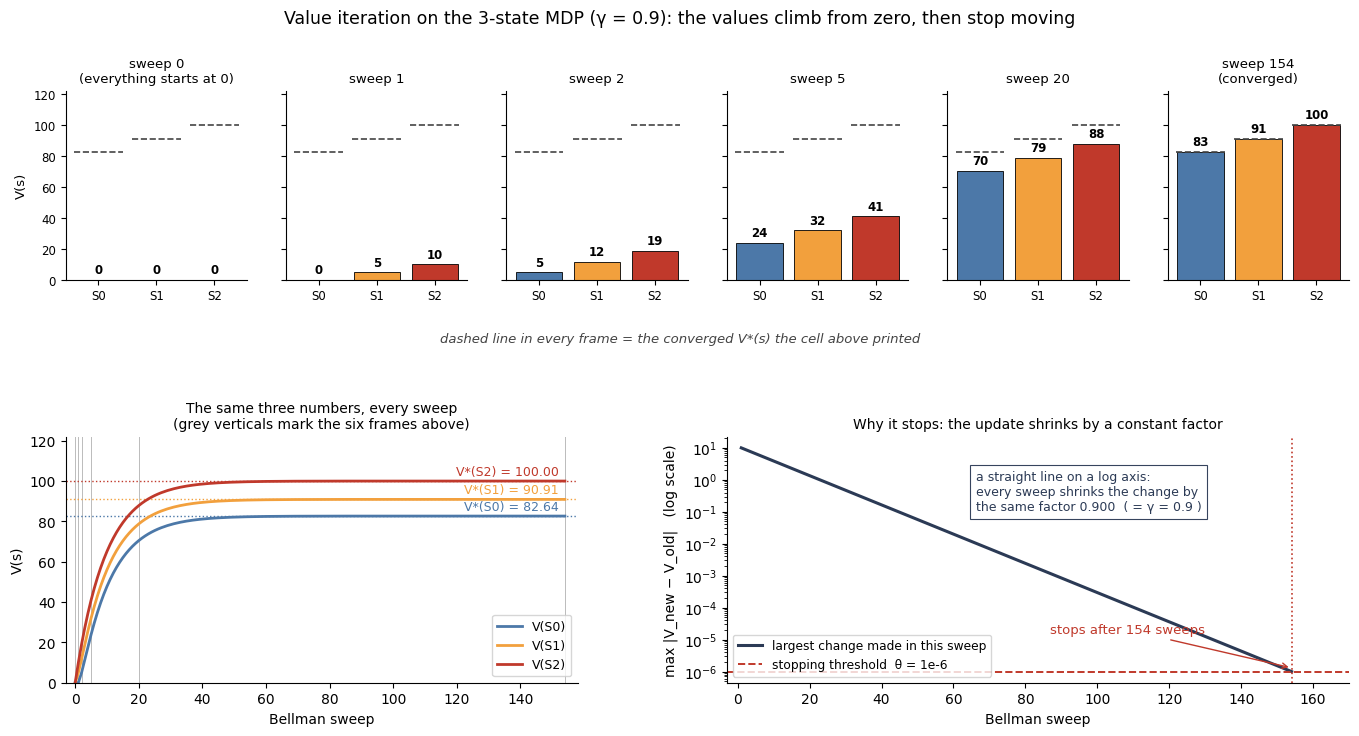

Step table — the value function at each frame drawn above:
 sweep      V(S0)      V(S1)      V(S2)    largest change in that sweep
     0     0.0000     0.0000     0.0000             —  (initialisation)
     1     0.0000     5.0000    10.0000                        1.00e+01
     2     4.9500    11.7500    19.0000                        9.00e+00
     5    23.8893    32.0278    40.9510                        6.56e+00
    20    70.4787    78.7514    87.8423                        1.35e+00
   154    82.6364    90.9091   100.0000                        9.98e-07

Sweeps to reach θ = 1e-6: 154. Measured shrink factor per sweep: 0.9000 (γ = 0.9).
First sweep only propagates the immediate rewards: V = (0, 5, 10) — each state has seen exactly one step into the future.


In [4]:
# SEE value iteration converge: the same three numbers, one Bellman sweep at a time.
# WHAT: top row = a six-frame storyboard of the value vector (V(S0), V(S1), V(S2)) at sweeps
#       0, 1, 2, 5, 20 and the sweep the loop above stopped on. The dashed line inside every
#       frame is the converged V*(s) that cell printed, so each frame shows how far the values
#       still have to travel. Bottom left = the same three numbers against sweep number.
#       Bottom right = the largest change any state made in each sweep, on a log axis, against
#       the theta = 1e-6 stopping threshold.
# WHY:  value iteration is a PROCESS, and "Converged after 154 iterations" is only its last line.
#       Two things the print-out cannot show: the values climb from zero and never overshoot,
#       and the size of the update shrinks by a CONSTANT factor every sweep. That constant is
#       gamma, and it is the whole reason the loop terminates - and roughly how long it takes.
#       (A static frame grid rather than an animation: it always renders, and it can be printed.)

# Re-run the same Bellman update, but keep every intermediate value function - value_iteration()
# above throws them away when it returns.
hist, deltas = [], []
V = {s: 0.0 for s in mdp.states}
hist.append(dict(V))                                  # sweep 0 = the all-zeros initialisation
for _ in range(500):
    V_old = dict(V)
    for s in mdp.states:
        V[s] = max(mdp.get_reward(s, a)
                   + mdp.gamma * sum(mdp.get_transition_prob(s, a, ns) * V_old[ns]
                                     for ns in mdp.states)
                   for a in mdp.actions)
    hist.append(dict(V))
    deltas.append(max(abs(V[s] - V_old[s]) for s in mdp.states))
    if deltas[-1] < 1e-6:
        break

n_sweeps = len(deltas)                                # same number the cell above printed
V_final = hist[-1]
frames = [0, 1, 2, 5, 20, n_sweeps]                   # the six snapshots in the storyboard
cols = {'S0': '#4c78a8', 'S1': '#f2a03d', 'S2': '#c0392b'}

fig = plt.figure(figsize=(13.8, 7.4))
gsp = fig.add_gridspec(2, 12, height_ratios=[1.0, 1.3], hspace=0.72, wspace=0.55)

for k, f in enumerate(frames):                        # --- the storyboard row ---
    ax = fig.add_subplot(gsp[0, 2 * k:2 * k + 2])
    vals = [hist[f][s] for s in mdp.states]
    ax.bar(mdp.states, vals, color=[cols[s] for s in mdp.states],
           edgecolor='black', linewidth=0.6)
    for si, s in enumerate(mdp.states):
        ax.hlines(V_final[s], si - 0.42, si + 0.42, color='#444', ls='--', lw=1.2, zorder=5)
        ax.text(si, vals[si] + 4, f"{vals[si]:.0f}", ha='center', fontsize=8.5, weight='bold')
    ax.set_ylim(0, 122)
    ax.set_title("sweep 0\n(everything starts at 0)" if f == 0 else
                 (f"sweep {f}\n(converged)" if f == n_sweeps else f"sweep {f}"), fontsize=9.5)
    if k == 0:
        ax.set_ylabel("V(s)", fontsize=9.5)
    else:
        ax.set_yticklabels([])
    ax.tick_params(labelsize=8.5)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.text(0.5, 0.535, "dashed line in every frame = the converged V*(s) the cell above printed",
         ha='center', fontsize=9.5, style='italic', color='#444')

ax1 = fig.add_subplot(gsp[1, 0:5])                    # --- values against sweep number ---
for s in mdp.states:
    ax1.plot(range(len(hist)), [h[s] for h in hist], color=cols[s], lw=2.0, label=f"V({s})")
    ax1.axhline(V_final[s], color=cols[s], ls=':', lw=1.0)
    ax1.text(n_sweeps - 2, V_final[s] + 3, f"V*({s}) = {V_final[s]:.2f}",
             color=cols[s], fontsize=9, ha='right')
for f in frames:
    ax1.axvline(f, color='#bbb', lw=0.7, zorder=0)    # where the six frames sit on this curve
ax1.set_xlabel("Bellman sweep"); ax1.set_ylabel("V(s)")
ax1.set_ylim(0, 122); ax1.set_xlim(-3, n_sweeps + 4)
ax1.set_title("The same three numbers, every sweep\n(grey verticals mark the six frames above)",
              fontsize=10)
ax1.legend(fontsize=9, loc='lower right')
for sp in ("top", "right"):
    ax1.spines[sp].set_visible(False)

ax2 = fig.add_subplot(gsp[1, 6:12])                   # --- why the loop stops ---
ax2.semilogy(range(1, n_sweeps + 1), deltas, color='#2b3a55', lw=2.2,
             label="largest change made in this sweep")
ax2.axhline(1e-6, color='#c0392b', ls='--', lw=1.4, label="stopping threshold  θ = 1e-6")
ax2.axvline(n_sweeps, color='#c0392b', ls=':', lw=1.2)
ratios = [deltas[i + 1] / deltas[i] for i in range(5, 60)]   # measured, not asserted
ax2.text(0.40, 0.70, "a straight line on a log axis:\nevery sweep shrinks the change by\n"
                     f"the same factor {np.median(ratios):.3f}  ( = γ = {mdp.gamma} )",
         transform=ax2.transAxes, fontsize=9, color='#2b3a55',
         bbox=dict(fc='white', ec='#2b3a55', lw=0.8, alpha=0.95))
ax2.annotate(f"stops after {n_sweeps} sweeps", xy=(n_sweeps, 1.3e-6), xytext=(0.52, 0.20),
             textcoords='axes fraction', fontsize=9.5, color='#c0392b',
             arrowprops=dict(arrowstyle='->', color='#c0392b'))
ax2.set_xlabel("Bellman sweep"); ax2.set_ylabel("max |V_new − V_old|   (log scale)")
ax2.set_title("Why it stops: the update shrinks by a constant factor", fontsize=10)
ax2.set_xlim(-3, n_sweeps + 16); ax2.legend(fontsize=8.8, loc='lower left')
for sp in ("top", "right"):
    ax2.spines[sp].set_visible(False)

fig.suptitle(f"Value iteration on the 3-state MDP (γ = {mdp.gamma}): "
             "the values climb from zero, then stop moving", fontsize=12.5, y=0.985)
fig.subplots_adjust(left=0.055, right=0.985, top=0.875, bottom=0.075)
plt.show()

# The step table behind the six frames - the same numbers, in print.
print("Step table — the value function at each frame drawn above:")
print(f"{'sweep':>6}{'V(S0)':>11}{'V(S1)':>11}{'V(S2)':>11}{'largest change in that sweep':>32}")
for f in frames:
    d = "—  (initialisation)" if f == 0 else f"{deltas[f - 1]:.2e}"
    print(f"{f:>6}{hist[f]['S0']:>11.4f}{hist[f]['S1']:>11.4f}{hist[f]['S2']:>11.4f}{d:>32}")
print(f"\nSweeps to reach θ = 1e-6: {n_sweeps}. "
      f"Measured shrink factor per sweep: {np.median(ratios):.4f} (γ = {mdp.gamma}).")
print(f"First sweep only propagates the immediate rewards: V = "
      f"({hist[1]['S0']:.0f}, {hist[1]['S1']:.0f}, {hist[1]['S2']:.0f}) "
      "— each state has seen exactly one step into the future.")


### 📊 Read the figure

**Top row — six snapshots of the same three bars.** At **sweep 0** the bars are flat on the floor: every
value starts at 0, and the dashed lines show how far away the answer is. Sweep 1 lifts S1 to 5 and S2 to 10 —
exactly their immediate rewards, because after one sweep each state has looked exactly one step into the
future. By sweep 5 the bars are roughly a third of the way up; by sweep 20 they are within about 15% of the
dashed lines; at sweep 154 the bars **touch** the dashed lines. Two things are worth saying out loud: the
bars only ever go **up** (value iteration approaches V\* from below when it starts at zero), and S2 is
always the tallest because it is the absorbing goal.

**Bottom left — the same story as three curves.** The grey verticals mark where the six frames sit. The
curves rise steeply for the first ~20 sweeps and then flatten onto their dotted asymptotes
V\*(S0) = 82.64, V\*(S1) = 90.91, V\*(S2) = 100.00 — the three numbers the cell above printed.

**Bottom right — why the loop is allowed to stop.** The dark line is the largest change any state made in
each sweep, on a log axis. It is a **straight line**, and a straight line on a log axis means a constant
ratio: each sweep changes the values by γ = 0.9 times the previous sweep's change. The measured factor
printed in the box is that ratio, computed from the run, not assumed. The line crosses the red θ = 1e-6
threshold at sweep 154 and the loop halts there.

**What this proves:** value iteration terminates not because someone chose a sweep budget, but because the
Bellman update is a **contraction** — it shrinks the remaining error by a factor of γ every pass. Push γ
closer to 1 and that line gets flatter, and the run gets longer. That is exactly what the next section measures.

## Part 3: Experiment — change one number, watch the decision change

The run above used **γ = 0.9** and produced V\* = (82.64, 90.91, 100.00), the policy `Right` in every state, converging after 154 sweeps.

Now hold everything else fixed and change **exactly one thing**: the discount factor. γ is not something you measure in the world — it is a modelling choice about how much a reward one step from now is worth compared to a reward now. So it is worth knowing precisely what that choice buys and what it costs.

Two experiments, both re-running the same Bellman update:

1. **Same MDP, four values of γ.** Does the *policy* move, or only the *values*?
2. **One reward changed** — `S0`'s `Left` action now pays **+3 immediately** instead of −1, while `Right` still pays 0 now and leads toward the +10 goal. Sweep γ again and let the code find the exact γ at which the recommended action reverses.


In [5]:
# COMPARATIVE EXPERIMENT: change ONE thing (gamma) and re-run value iteration.
# Why a second implementation? The value_iteration() above prints a running commentary and does
# not report how many sweeps it needed. This one is silent and returns the sweep count, so we can
# put many runs side by side in a table. The Bellman update inside is line-for-line the same.

def solve_quietly(reward_table, gamma, theta=1e-6, max_iterations=500):
    """Value iteration, silent. Returns (V, policy, sweeps); sweeps is None if it never converged."""
    V = {s: 0.0 for s in states}
    sweeps = None
    for i in range(max_iterations):
        V_old = V.copy()
        for s in states:
            # Q(s,a) = R(s,a) + gamma * sum_s' P(s'|s,a) V(s')  -- the same update as above
            V[s] = max(reward_table[s][a] + gamma * sum(transitions[s][a].get(ns, 0.0) * V_old[ns]
                                                        for ns in states)
                       for a in actions)
        if max(abs(V[s] - V_old[s]) for s in states) < theta:
            sweeps = i + 1          # converged: record how many sweeps it took
            break
    # Read the greedy policy off the converged values, exactly as value_iteration() does.
    policy = {s: max(actions,
                     key=lambda a: reward_table[s][a] + gamma * sum(transitions[s][a].get(ns, 0.0) * V[ns]
                                                                   for ns in states))
              for s in states}
    return V, policy, sweeps


print("=" * 78)
print("EXPERIMENT 1 - same MDP, same rewards, four discount factors")
print("=" * 78)
print(f"{'gamma':>6} {'sweeps':>8}  {'V*(S0)':>9} {'V*(S1)':>9} {'V*(S2)':>9}   policy (S0, S1, S2)")
runs = {}
for g in [0.0, 0.5, 0.9, 0.99]:
    V, pol, sweeps = solve_quietly(rewards, g)
    runs[g] = (V, pol, sweeps)
    shown = sweeps if sweeps is not None else "500+"   # 500 is the iteration cap
    print(f"{g:>6} {shown:>8}  {V['S0']:>9.2f} {V['S1']:>9.2f} {V['S2']:>9.2f}   "
          f"{pol['S0']}, {pol['S1']}, {pol['S2']}")

# Conclusions are DERIVED from the runs above, never hard-coded.
policies = {tuple(runs[g][1][s] for s in states) for g in runs}
v_low, v_high = runs[0.0][0]['S2'], runs[0.99][0]['S2']
print()
print("What these numbers actually support:")
print(f"   - The optimal POLICY is identical at every gamma tested "
      f"({'unchanged' if len(policies) == 1 else 'it changed'}): "
      + ", ".join(runs[0.9][1][s] for s in states))
print(f"   - The VALUES are not: V*(S2) runs from {v_low:.2f} at gamma=0 to {v_high:.2f} at gamma=0.99.")
print(f"   - The COST of solving is not either: {runs[0.0][2]} sweeps at gamma=0, "
      f"{runs[0.9][2]} at gamma=0.9, and at gamma=0.99 the loop hit its 500-sweep cap")
print( "     WITHOUT reaching the 1e-6 threshold - it returned a number anyway, unconverged.")
print()

print("=" * 78)
print("EXPERIMENT 2 - change ONE reward, then sweep gamma again")
print("=" * 78)
print("Only S0's 'Left' reward changes: -1  ->  +3.")
print("'Left' now pays 3 immediately but mostly loops back to S0 (p=0.8).")
print("'Right' still pays 0 now, but moves toward S1/S2 where the +10 goal lives.")
print()

# Copy the reward table and change exactly one entry.
rewards_myopic = {s: dict(a_r) for s, a_r in rewards.items()}
rewards_myopic['S0']['Left'] = 3

print(f"{'gamma':>6}   best action in S0   {'V*(S0)':>9}")
for g in [0.0, 0.3, 0.5, 0.6, 0.9]:
    V, pol, _ = solve_quietly(rewards_myopic, g)
    print(f"{g:>6}   {pol['S0']:<17} {V['S0']:>9.2f}")

# Let the code find the crossover instead of asserting it: bisect on gamma.
lo, hi = 0.0, 0.9
for _ in range(40):
    mid = (lo + hi) / 2
    if solve_quietly(rewards_myopic, mid)[1]['S0'] == 'Left':
        lo = mid          # still myopic: grab the +3
    else:
        hi = mid          # patient enough to invest
print()
print(f"   Crossover found by bisection: gamma ~ {lo:.3f}")
print( "   Below it, the optimal action in S0 is Left  - take the 3 now.")
print( "   Above it, the optimal action in S0 is Right - give up the 3 to reach the +10 sooner.")
print()
print( "   Nothing about the world changed between those two rows. One number in the MODEL")
print( "   changed, and the recommended decision reversed. gamma is a value judgement")
print( "   wearing a Greek letter, and somebody on your team has to own it.")


EXPERIMENT 1 - same MDP, same rewards, four discount factors
 gamma   sweeps     V*(S0)    V*(S1)    V*(S2)   policy (S0, S1, S2)
   0.0        2       0.00      5.00     10.00   Right, Right, Right
   0.5       25       7.00     13.33     20.00   Right, Right, Right
   0.9      154      82.64     90.91    100.00   Right, Right, Right
  0.99     500+     974.61    983.53    993.43   Right, Right, Right

What these numbers actually support:
   - The optimal POLICY is identical at every gamma tested (unchanged): Right, Right, Right
   - The VALUES are not: V*(S2) runs from 10.00 at gamma=0 to 993.43 at gamma=0.99.
   - The COST of solving is not either: 2 sweeps at gamma=0, 154 at gamma=0.9, and at gamma=0.99 the loop hit its 500-sweep cap
     WITHOUT reaching the 1e-6 threshold - it returned a number anyway, unconverged.

EXPERIMENT 2 - change ONE reward, then sweep gamma again
Only S0's 'Left' reward changes: -1  ->  +3.
'Left' now pays 3 immediately but mostly loops back to S0 (p=0.8

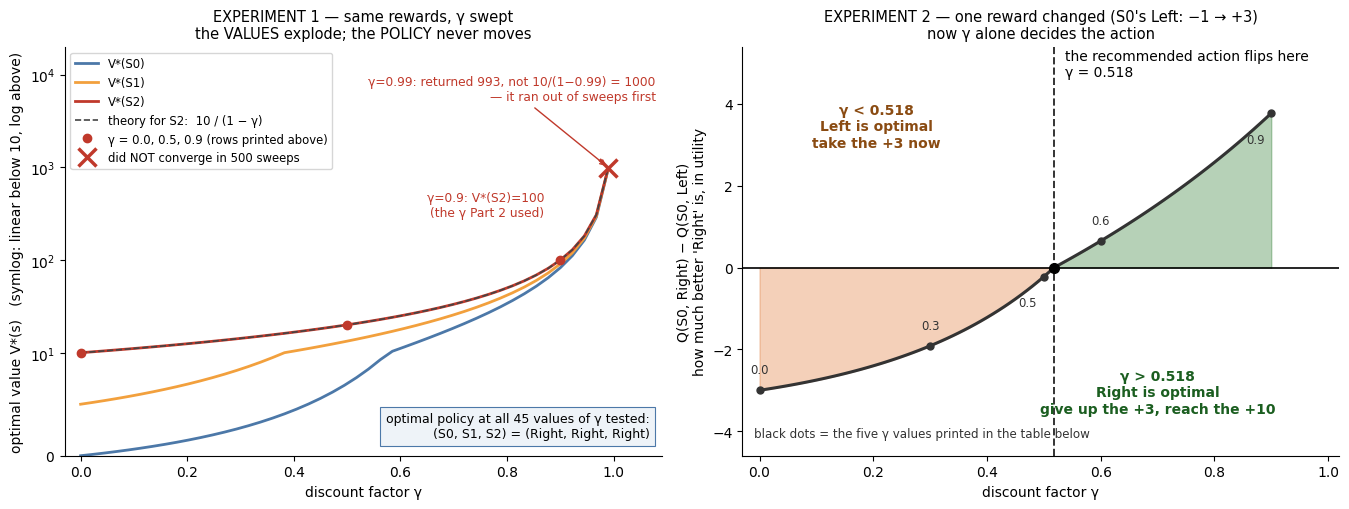

The right-hand curve, at the five marked points:
 gamma   Q(S0,Left)   Q(S0,Right)   difference   winner
   0.0         3.00          0.00        -3.00   Left
   0.3         4.61          2.70        -1.91   Left
   0.5         7.22          7.00        -0.22   Left
   0.6        10.49         11.14         0.65   Right
   0.9        78.86         82.64         3.77   Right

Sign change located by bisection at γ = 0.518 — the dashed line in the right panel.
Policies found across 45 values of γ in Experiment 1: [('Right', 'Right', 'Right')] — one policy, unchanged.
Runs that hit the 500-sweep cap (marked with a red x): [0.99]


In [6]:
# SEE the two experiments above, as pictures.
# WHAT: left  - V*(s) for all three states as gamma sweeps from 0 to 0.99, plus the closed-form
#               10/(1-gamma) that S2 must obey; runs that hit the 500-sweep cap are marked.
#               The y-axis is symlog (linear below 10, logarithmic above) because the values span
#               0 to ~1000 and a plain linear axis would flatten everything below gamma = 0.9.
#        right - the SAME MDP with S0's 'Left' reward changed to +3, showing how much better
#               'Right' is than 'Left' in S0, as a single quantity, for every gamma.
# WHY:  the tables above print five rows each; the eye cannot extrapolate a table. The left panel
#       shows the values exploding while the policy stays put, and the right panel shows the one
#       thing that actually matters to a decision maker: the point where the recommendation flips.

def q_value(s, a, V, reward_table, g):
    """Q(s,a) = R(s,a) + g * sum_s' P(s'|s,a) V(s') — the same expression solve_quietly() maximises."""
    return reward_table[s][a] + g * sum(transitions[s][a].get(ns, 0.0) * V[ns] for ns in states)

# --- Experiment 1, swept densely instead of at four points ---
gammas = np.linspace(0.0, 0.99, 45)
V_by_state = {s: [] for s in states}
policies_seen, unconverged = set(), []
for g in gammas:
    V, pol, sweeps = solve_quietly(rewards, g)
    for s in states:
        V_by_state[s].append(V[s])
    policies_seen.add(tuple(pol[s] for s in states))
    if sweeps is None:
        unconverged.append((g, V['S2']))

# --- Experiment 2, swept densely; positive means 'Right' is the better action in S0 ---
rewards_myopic_fig = {s: dict(a_r) for s, a_r in rewards.items()}
rewards_myopic_fig['S0']['Left'] = 3
g_grid = np.linspace(0.0, 0.9, 91)
qL, qR = [], []
for g in g_grid:
    V, _, _ = solve_quietly(rewards_myopic_fig, g)
    qL.append(q_value('S0', 'Left', V, rewards_myopic_fig, g))
    qR.append(q_value('S0', 'Right', V, rewards_myopic_fig, g))
qL, qR = np.array(qL), np.array(qR)
advantage = qR - qL
lo, hi = 0.0, 0.9                                     # same bisection as the cell above
for _ in range(40):
    mid = (lo + hi) / 2
    if solve_quietly(rewards_myopic_fig, mid)[1]['S0'] == 'Left':
        lo = mid
    else:
        hi = mid
crossover = lo

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))
cols = {'S0': '#4c78a8', 'S1': '#f2a03d', 'S2': '#c0392b'}

ax = axes[0]                                          # --- values explode, policy does not move ---
for s in states:
    ax.plot(gammas, V_by_state[s], color=cols[s], lw=2.0, label=f"V*({s})")
ax.plot(gammas, 10 / (1 - gammas), color='#444', ls='--', lw=1.2,
        label="theory for S2:  10 / (1 − γ)")
ax.set_yscale('symlog', linthresh=10)
marked = [(g, solve_quietly(rewards, g)[0]['S2']) for g in [0.0, 0.5, 0.9]]
ax.plot([g for g, _ in marked], [v for _, v in marked], 'o', color='#c0392b', ms=6, zorder=5,
        label="γ = 0.0, 0.5, 0.9 (rows printed above)")
g9, v9 = marked[-1]                                   # tie the picture back to Part 2's run
ax.annotate(f"γ={g9}: V*(S2)={v9:.0f}\n(the γ Part 2 used)", xy=(g9, v9),
            xytext=(g9 - 0.03, v9 * 3.0), fontsize=8.8, color='#c0392b', ha='right')
if unconverged:
    ax.plot([g for g, _ in unconverged], [v for _, v in unconverged], 'x', color='#c0392b',
            ms=13, mew=2.5, zorder=6, label="did NOT converge in 500 sweeps")
    gu, vu = unconverged[0]
    ax.annotate(f"γ={gu:.2f}: returned {vu:.0f}, not 10/(1−{gu:.2f}) = {10/(1-gu):.0f}\n"
                "— it ran out of sweeps first",
                xy=(gu, vu), xytext=(0.99, 0.93), textcoords='axes fraction', fontsize=8.8,
                color='#c0392b', ha='right', va='top',
                arrowprops=dict(arrowstyle='->', color='#c0392b'))
ax.set_xlim(-0.03, 1.09); ax.set_ylim(0, 20000)   # headroom so the notes sit clear of the curves
ax.set_xlabel("discount factor γ")
ax.set_ylabel("optimal value V*(s)   (symlog: linear below 10, log above)")
ax.set_title("EXPERIMENT 1 — same rewards, γ swept\nthe VALUES explode; the POLICY never moves",
             fontsize=10.5)
ax.legend(fontsize=8.4, loc='upper left')
ax.text(0.98, 0.045,
        f"optimal policy at all {len(gammas)} values of γ tested:\n"
        f"(S0, S1, S2) = ({', '.join(sorted(policies_seen)[0])})"
        if len(policies_seen) == 1 else f"{len(policies_seen)} different policies appeared",
        transform=ax.transAxes, fontsize=9, ha='right',
        bbox=dict(fc='#eef3f8', ec='#4c78a8', lw=0.8))
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

ax = axes[1]                                          # --- the decision flips ---
ax.axhline(0, color='black', lw=1.2)
ax.fill_between(g_grid, advantage, 0, where=advantage < 0, color='#e07b39', alpha=0.35,
                interpolate=True)
ax.fill_between(g_grid, advantage, 0, where=advantage >= 0, color='#2e7d32', alpha=0.35,
                interpolate=True)
ax.plot(g_grid, advantage, color='#333', lw=2.2)
ax.axvline(crossover, color='#333', ls='--', lw=1.4)
ax.plot([crossover], [0], 'o', color='black', ms=7, zorder=6)
ax.text(crossover + 0.02, 5.35, f"the recommended action flips here\nγ = {crossover:.3f}",
        fontsize=10, ha='left', va='top')
ax.text(0.205, 3.45, f"γ < {crossover:.3f}\nLeft is optimal\ntake the +3 now",
        ha='center', va='center', color='#8a4b12', fontsize=10, weight='bold')
ax.text(0.70, -3.05, f"γ > {crossover:.3f}\nRight is optimal\ngive up the +3, reach the +10",
        ha='center', va='center', color='#1b5e20', fontsize=10, weight='bold')
for g in [0.0, 0.3, 0.5, 0.6, 0.9]:                   # the rows the table below prints
    i = int(np.argmin(np.abs(g_grid - g)))
    ax.plot([g_grid[i]], [advantage[i]], 'o', color='#333', ms=5, zorder=5)
    below = g in (0.5, 0.9)                           # keep these two clear of other text
    dy, ha = (-0.72, 'right') if below else (0.42, 'center')
    ax.annotate(f"{g}", xy=(g_grid[i], advantage[i]),
                xytext=(g_grid[i] - (0.012 if below else 0), advantage[i] + dy),
                fontsize=8.4, ha=ha, color='#333')
ax.text(0.02, 0.045, "black dots = the five γ values printed in the table below",
        transform=ax.transAxes, fontsize=8.6, color='#333')
ax.set_xlim(-0.03, 1.02); ax.set_ylim(-4.6, 5.4)
ax.set_xlabel("discount factor γ")
ax.set_ylabel("Q(S0, Right) − Q(S0, Left)\nhow much better 'Right' is, in utility")
ax.set_title("EXPERIMENT 2 — one reward changed (S0's Left: −1 → +3)\nnow γ alone decides the action",
             fontsize=10.5)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()

print("The right-hand curve, at the five marked points:")
print(f"{'gamma':>6}{'Q(S0,Left)':>13}{'Q(S0,Right)':>14}{'difference':>13}   winner")
for g in [0.0, 0.3, 0.5, 0.6, 0.9]:
    i = int(np.argmin(np.abs(g_grid - g)))
    win = 'Right' if advantage[i] > 0 else 'Left'
    print(f"{g:>6}{qL[i]:>13.2f}{qR[i]:>14.2f}{advantage[i]:>13.2f}   {win}")
print(f"\nSign change located by bisection at γ = {crossover:.3f} — the dashed line in the right panel.")
print(f"Policies found across {len(gammas)} values of γ in Experiment 1: "
      f"{sorted(policies_seen)} — {'one policy, unchanged' if len(policies_seen)==1 else 'more than one'}.")
if unconverged:
    print(f"Runs that hit the 500-sweep cap (marked with a red x): "
          f"{[round(float(g), 3) for g, _ in unconverged]}")


### 📊 Read the figure

**Left — the values run away; the decision does not.** Three coloured curves, one per state, as γ is swept
across 45 values. The vertical axis is **symlog**: linear from 0 to 10, logarithmic above, so a range from
0 to about 1000 fits on one axis without crushing the low-γ end. The red curve for S2 sits **on top of the
dashed theory line 10/(1 − γ)** — the geometric series from Part 2, now verified at 45 different discount
factors rather than one. The three red dots are the γ = 0, 0.5 and 0.9 rows of the table above (V\*(S2) =
10, 20, 100). The red **×** at γ = 0.99 marks the only run in the sweep that hit the 500-sweep cap: it
returned 993 where the exact answer is 1000, and it returned it *unconverged*. The box at the bottom right
is written from the runs themselves: across all 45 γ values the optimal policy was the same triple,
`(Right, Right, Right)`. **The values moved by two orders of magnitude and the policy never moved at all.**

**Right — one changed reward, and now γ decides.** With S0's `Left` reward raised from −1 to +3, the curve
plots a single quantity: **Q(S0, Right) − Q(S0, Left)**, how much better the patient action is than the
greedy one. Where the curve is **below zero (orange)** the greedy action wins; where it is **above zero
(green)** the patient action wins. It crosses zero exactly once, at the γ = 0.518 found by bisection in the
cell above — the dashed vertical line. The black dots are the five rows of the printed table, so a student
can point at a row and at the curve and see the same number.

**What this proves:** γ is not a tuning knob that only rescales the answer. In the original MDP it moved the
values from 10 to 993 and left the recommendation untouched; after a single reward changed, it became the
only thing separating "take the money now" from "invest". Nothing about the world differs between the two
sides of that dashed line. A modelling choice does.

## 💬 Discuss

The two experiments above are the evidence. None of these has a settled answer.

1. **Who chooses γ, and how would you defend the choice to a client?** In Experiment 2 the optimal action reverses at γ ≈ 0.518. Below it the model says take the money now; above it, invest. For a Saudi retailer deciding how much stock to hold before Ramadan, or a maintenance team deciding whether to replace a part now or run it another quarter, what would you set γ to — and what evidence would you bring? Is γ a finance question, an engineering question, or an ethics question when the "reward" is a patient outcome?
2. **In Experiment 1 the policy never moved while the values moved by two orders of magnitude.** A colleague concludes: "the values do not matter, only the policy does — stop worrying about γ." Argue against them. Name a situation where the *values* are the deliverable, not the policy.
3. **At γ = 0.99, value iteration hit its 500-sweep cap and returned numbers anyway, with no error.** The policy read off those unconverged values happened to be right. Would you ship code that behaves this way? What would you change — raise the cap, loosen the threshold, return a convergence flag, refuse to return at all? Each choice moves a risk somewhere; say where.

---


## ⚠️ Where this breaks

Value iteration is exact, terminates, and comes with strong guarantees — and every one of those guarantees rests on an assumption you should be able to state out loud.

- **You must already know P(s′ | s, a) and R(s, a).** Value iteration is *planning*, not learning: it computes an optimal policy from a model that somebody handed it. In this notebook, both tables were typed into the cell. When you do not have them — which is most of the time — you need reinforcement learning, which is exactly where Course 09 picks this up. Everything here is the answer to "what should I do *if the model is right*".
- **γ is a modelling choice, and Experiment 2 shows it choosing the decision.** At γ ≈ 0.518 the optimal action reverses. It is not measured, it is not learned, and it is not neutral. Discounting a patient's future health at 0.9 per step is an ethical statement, not a hyperparameter.
- **γ close to 1 makes the arithmetic slow and the values huge.** Convergence of value iteration is governed by γ: 2 sweeps at γ = 0, 154 at 0.9, and at 0.99 the loop exhausted its 500-sweep cap without reaching the 1e-6 threshold. For infinite-horizon problems where you genuinely do not want to discount, you need average-reward formulations or policy iteration instead.
- **The state space is the wall — the curse of dimensionality.** Value iteration sweeps *every* state on *every* iteration. Three states is trivial. A warehouse with 20 products at 100 stock levels each has 100²⁰ states, and no amount of engineering will enumerate them. Real systems use function approximation, factored representations or sampling; that is the whole reason deep reinforcement learning exists.
- **The Markov assumption must actually hold.** "The next state depends only on the current state and action" is a strong claim about your state encoding. If the right decision depends on something not in the state — how long the machine has been running, what the customer bought last month — the model is wrong, and value iteration will return a confidently optimal policy for the wrong problem.
- **The reward function is written by a human, and the agent will exploit exactly what you wrote.** `S2` pays +10 every step forever, so the optimal policy is to sit in S2 and collect — which is right here because S2 *is* the goal. Change the numbers carelessly and you get an agent that games the reward instead of doing the job. Reward specification is the hard part of every applied MDP.
- **The cheaper alternative.** If the horizon is short and the branching small, plain expected-utility calculation (Unit 3, notebook 01) or a decision tree drawn on a whiteboard answers the question without any of this machinery. And if the MDP has already been solved *in general* for your problem class — as Scarf did for inventory in 1960 — the professional move is to look up the known optimal policy shape and fit its two parameters, not to re-derive it.

---


## Summary

### Key Concepts:
1. **MDP Components**: States, actions, transition probabilities, rewards, discount factor
2. **Value Function V(s)**: Expected cumulative reward from state s
3. **Value Iteration**: Algorithm to compute optimal value function
4. **Policy**: Mapping from states to actions

### Applications:
- Robotics (path planning)
- Game AI
- Resource allocation
- Autonomous systems

**Reference:** Course 02, Unit 3: "Implementing simple MDPs and value iteration algorithms"


## 📚 References

1. Bellman, R. (1957). *A Markovian Decision Process*. Journal of Mathematics and Mechanics 6(5), 679-684. (the MDP and the Bellman equation)
2. Schrittwieser, J., et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model*. Nature 588, 604-609. <https://arxiv.org/abs/1911.08265> (MuZero: planning in a learned MDP)
3. DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv preprint. <https://arxiv.org/abs/2501.12948> (the largest 2025 application of the MDP framing: each generated token is an action, and a verifiable answer is the reward)
4. Luo, X., Zhang, Y., He, Z., Wang, Z., Zhao, S., Li, D., Qiu, L. K., & Yang, Y. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning*. arXiv preprint. <https://arxiv.org/abs/2508.03680> (treats an existing agent's execution as an MDP so it can be trained rather than only prompted)
5. Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.), Chapters 3-4 (Finite MDPs; Dynamic Programming). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html>